# B5 — Machine Learning tabulaire : prédire la panne

Premier modèle de **classification binaire** (« panne dans les prochaines Hh ? ») à partir
du **gold** InduSense (`gold.dataset` / `data/processed/gold_dataset.parquet`) — **pas** du
dataset générique décrit dans le brief du TP (`b5_maintenance_ml.md`) : on repart de notre
schéma réel.

**Deux pièges à éviter** : la **fuite temporelle** (split chronologique existant, pas de
split aléatoire ; RUL et les 3 autres horizons exclus des features) et le **déséquilibre de
classes** (16,3 % de positifs à 24 h — PR-AUC en métrique primaire, jamais l'accuracy seule).

**Horizon retenu** : 24 h (compromis « raisonnable », cf. `reports/cadrage.md`).

> **Prérequis** : couche gold construite (`03_gold.ipynb` / `uv run indusense-gold`).

## 1. Entraînement & comparaison

Équivalent notebook de `uv run indusense-train` : charge le gold, construit 3 pipelines
(régression logistique, Random Forest, XGBoost — prétraitement fit-train : imputation
médiane, standardisation, one-hot), les évalue sur le split test, et lance une validation
croisée temporelle (`TimeSeriesSplit`) pour une estimation robuste.

In [1]:
from indusense.ml import training

meta = training.run()
print(f"run : {meta['run_id']}  |  horizon : {meta['horizon']}h  |  seuil : {meta['threshold']}")
print(f"gagnant : {meta['winner']}  (PR-AUC={meta['pr_auc_test']}, ROC-AUC={meta['roc_auc_test']})"
)

run : 202607061646  |  horizon : 24h  |  seuil : 0.5
gagnant : xgboost  (PR-AUC=0.4495, ROC-AUC=0.7098)


## 2.1 Tableau comparatif

Trié par **PR-AUC** décroissant (métrique primaire — classes déséquilibrées). La 1ère ligne
est le modèle retenu, qui passe au module **B7** (optimisation).

In [2]:
import pandas as pd

comparison = pd.DataFrame(meta["comparison"])
comparison

,model,pr_auc_test,roc_auc_test,pr_auc_cv_mean,pr_auc_cv_std,precision,recall,f1,tn,fp,fn,tp
0,xgboost,0.449497,0.709803,0.393020,0.041143,0.449093,0.389477,0.417166,14766,1580,2019,1288
1,logreg,0.428257,0.716126,0.353781,0.053192,0.269401,0.661324,0.382845,10415,5931,1120,2187
2,random_forest,0.422528,0.739065,0.401541,0.040938,0.673333,0.213789,0.324535,16003,343,2600,707


## 2.2 Explication des métriques

| Colonne | Signification |
|---|---|
| `model` | Nom du pipeline (`logreg`, `random_forest`, `xgboost`). |
| `pr_auc_test` | **PR-AUC** (Average Precision) sur le split **test** — métrique **primaire** : robuste au déséquilibre de classes, contrairement à l'accuracy. |
| `roc_auc_test` | ROC-AUC sur le split test — métrique **secondaire**, complémentaire mais plus optimiste que la PR-AUC quand les classes sont déséquilibrées. |
| `pr_auc_cv_mean` / `pr_auc_cv_std` | Moyenne / écart-type de la PR-AUC sur 5 folds de **validation croisée temporelle** (`TimeSeriesSplit`, triée par horodatage seul) — estime la **robustesse** du score au-delà du seul split test (un score test isolé peut être optimiste ou pessimiste par chance). |
| `precision` | Parmi les alertes émises (au seuil 0.5), proportion de vraies pannes. Une precision basse = beaucoup de **fausses alertes**. |
| `recall` | Parmi les pannes réelles, proportion détectée par le modèle (au seuil 0.5). Un recall bas = beaucoup de **pannes manquées** — le coût métier prioritaire ici (cf. `reports/cadrage.md` §5). |
| `f1` | Moyenne harmonique precision/recall — résumé en un seul chiffre, mais moins informatif que le couple precision/recall pour arbitrer un coût métier asymétrique. |
| `tn`, `fp`, `fn`, `tp` | Cellules de la **matrice de confusion** au seuil 0.5 : vrais négatifs, faux positifs (fausses alertes), faux négatifs (pannes manquées), vrais positifs. |

**Seuil fixe à 0.5** pour tout le tableau (choix motivé du seuil reporté à **B7**) : `precision`/`recall`/`f1`/`tn`/`fp`/`fn`/`tp` en dépendent directement, alors que `pr_auc_test`/`roc_auc_test`/`pr_auc_cv_mean`/`pr_auc_cv_std` sont indépendantes du seuil (calculées sur les probabilités, pas les classes prédites).

## 3. Figures

1. Comparaison PR-AUC / ROC-AUC par modèle (test).
2. Matrice de confusion du gagnant (seuil fixe 0.5).
3. PR-AUC en validation croisée temporelle (moyenne ± écart-type, 5 folds chronologiques).

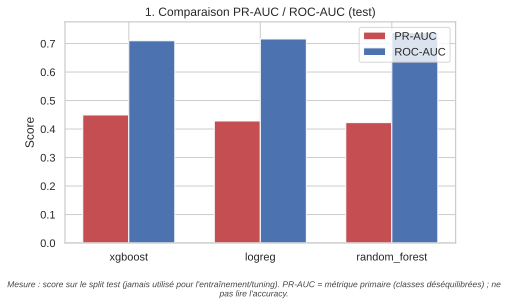

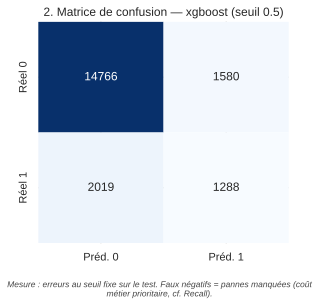

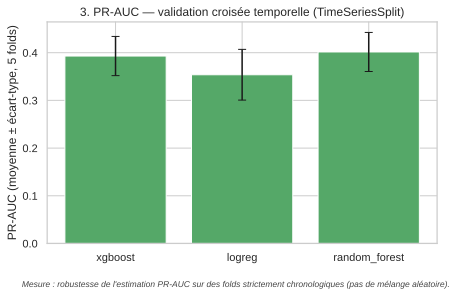

In [3]:
from IPython.display import SVG, display

from indusense import config

run_dir = sorted(p for p in config.ML_DIR.glob("2*") if p.is_dir())[-1]
for fig in sorted((run_dir / "figures").glob("*.svg")):
    display(SVG(filename=str(fig)))

## 4. MLflow

Chaque modèle est loggé (params, métriques, figure de confusion, pipeline) dans une
expérience MLflow locale (backend SQLite, `artifacts/ml/mlflow.db`, non versionné).

Pour explorer les runs dans l'UI :

```bash
uv run mlflow ui --backend-store-uri sqlite:///artifacts/ml/mlflow.db
```

➡️ **Conclusions**

- **Modèle retenu → B7** : celui en tête du tableau comparatif (PR-AUC test). Sur le run de
  référence (gold reconstruit après le correctif anti-fuite du 2026-07-06), c'est **XGBoost**
  qui l'emporte de peu sur la régression logistique et le Random Forest — l'écart reste
  faible, les trois modèles restent des candidats légitimes pour l'optimisation en B7.
- **Lecture de la matrice de confusion** : les **faux négatifs** (pannes manquées) sont le
  coût métier prioritaire (cf. `reports/cadrage.md` §5) — plus critiques que les faux
  positifs (sur-alerte). Le seuil fixe (0.5) et son arbitrage motivé sont reportés à B7.
- **Déséquilibre géré** sans SMOTE : `class_weight="balanced"` (LogReg/RF) et
  `scale_pos_weight` fit-train (XGBoost) — cohérent avec le choix du brief (SMOTE hors
  périmètre B5).
- **Anti-fuite** : imputation médiane fit-train dans la Pipeline (referme le correctif
  silver du jour), RUL et les 3 autres horizons exclus des features, split chronologique
  respecté, validation croisée strictement temporelle.